In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
import time

/Users/rahulprajapati/miniconda3/envs/langchain/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
# define state:

class CrashState(TypedDict):

    input: str
    state1: str 
    state2: str
    state3: str 

In [3]:
def state1(state: CrashState):
    print('Step 1 Executed')
    return {'state1': 'Done', 'input': state['input']}

def state2(state: CrashState):
    print("Step 2 hanging...... now manually interrupt from the notebook toolbar")
    time.sleep(30)
    return {'state2': 'Done'}

def state3(state: CrashState):
    print('Step 3 Executed')
    return {'Done': True}



In [4]:
# Define StateGraph:

graph = StateGraph(CrashState)

# add node
graph.add_node('state1', state1)
graph.add_node('state2', state2)
graph.add_node('state3', state3)

# add edge

graph.add_edge(START, 'state1')

graph.add_edge('state1', 'state2')

graph.add_edge('state2', 'state3')

graph.add_edge('state3', END)


# define checkpointer
checkpointer = InMemorySaver()


# Comiple

workflow = graph.compile(checkpointer = checkpointer )

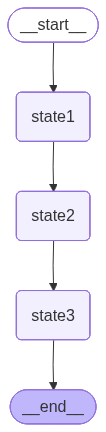

In [5]:
# show the workflow

from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)


In [6]:
# execute the workflow.

try:
    workflow.invoke({'input':'start'}, config={'configurable': {'thread_id':'1'}})
except KeyboardInterrupt:
    print('kernal manually interrupted')


Step 1 Executed
Step 2 hanging...... now manually interrupt from the notebook toolbar
kernal manually interrupted


In [7]:
# invoke the current state:
workflow.get_state({'configurable': {'thread_id':'1'}})

StateSnapshot(values={'input': 'start', 'state1': 'Done'}, next=('state2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156a35-c19b-620e-8001-5d6c2d3b1b78'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-23T12:31:45.004183+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156a35-c198-6d56-8000-51db4a36eda0'}}, tasks=(PregelTask(id='3ad4626b-7941-2f97-a70a-3d706ce9e5b1', name='state2', path=('__pregel_pull', 'state2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [8]:
# Now Resume the work
final_state = workflow.invoke(None, config={'configurable': {'thread_id':'1'}})
print('Final State', final_state)


Step 2 hanging...... now manually interrupt from the notebook toolbar
Step 3 Executed
Final State {'input': 'start', 'state1': 'Done', 'state2': 'Done'}


In [9]:
# fetch the state history

list(workflow.get_state_history(config={'configurable': {'thread_id':'1'}}))

[StateSnapshot(values={'input': 'start', 'state1': 'Done', 'state2': 'Done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156a37-46c0-6186-8003-e8974f64715a'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-23T12:32:25.808922+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156a37-46bb-6974-8002-f623edcf1f7b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'state1': 'Done', 'state2': 'Done'}, next=('state3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156a37-46bb-6974-8002-f623edcf1f7b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-23T12:32:25.807061+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156a35-c19b-620e-8001-5d6c2d3b1b78'}}, tasks=(PregelTask(id='cc4721bb-52a6-07b9-fe02-3ff7c6b0ca86', name='state3', path=